# Práctica de Percepción: Procesamiento de Imágenes y Geometría
## Introducción y Librerías

Para esta práctica utilizaremos OpenCV (para el procesamiento), NumPy (para el cálculo matricial) y Matplotlib (para la visualización).

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Función auxiliar para mostrar imágenes en Jupyter
def imshow(img, title="Imagen", cmap=None):
    plt.figure(figsize=(8, 6))
    if len(img.shape) == 3: # Imagen en color
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else: # Imagen en escala de grises
        plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

# Ejercicio 1: Espacios de Color y Filtrado (RGB vs HSV)

Objetivo: Comprender que el modelo HSV separa el brillo (Value) del color (Hue), lo cual facilita el filtrado frente a condiciones de iluminación variables.

    1) Lee una imagen en color.

    2) Transfórmala a RGB y HSV.

    3) Aplica una máscara para extraer un color específico (por ejemplo, el rojo) en ambos espacios.

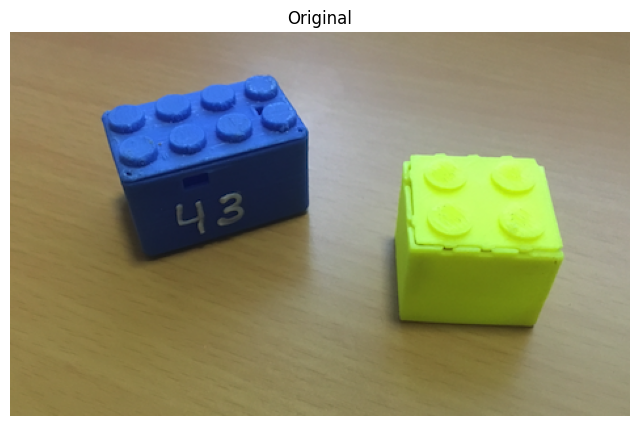

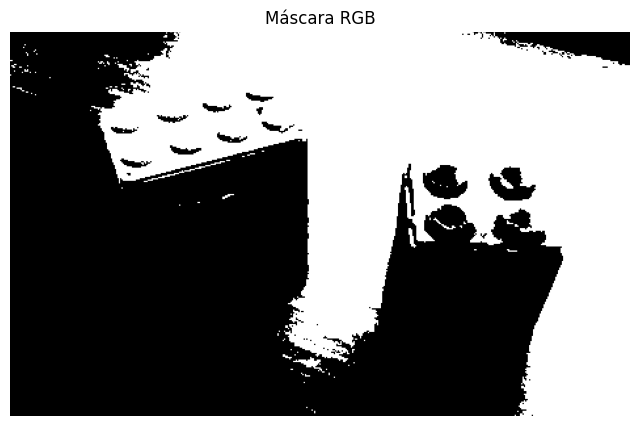

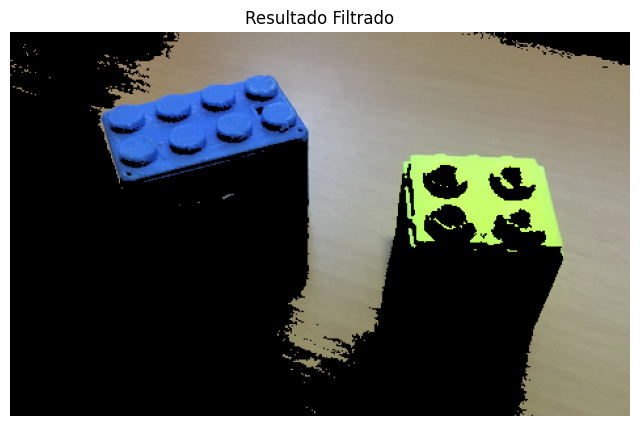

In [8]:
# 1. Cargar imagen
img = cv2.imread('images/Lego.png')

# 2. Transformaciones
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# 3. Filtrado por color en RGB

lower = np.array([0, 50, 100])
upper = np.array([255, 255, 255])
mask_rgb = cv2.inRange(img_rgb, lower, upper)
res_rgb = cv2.bitwise_and(img, img, mask=mask_rgb)

imshow(img, "Original")
imshow(mask_rgb, "Máscara RGB", cmap='gray')
imshow(res_rgb, "Resultado Filtrado")



Ejercicio propuesto: aplicar el filtro utilizando HSV y comparar

In [3]:
#TO DO

# Ejercicio 2: Transformaciones Geométricas y Distorsión

Objetivo: Aplicar matrices de transformación (traslación, rotación, escala) y simular la distorsión radial que introducen las lentes reales.

A) Transformaciones Afines

Utilizaremos coordenadas homogéneas para aplicar traslación y rotación.

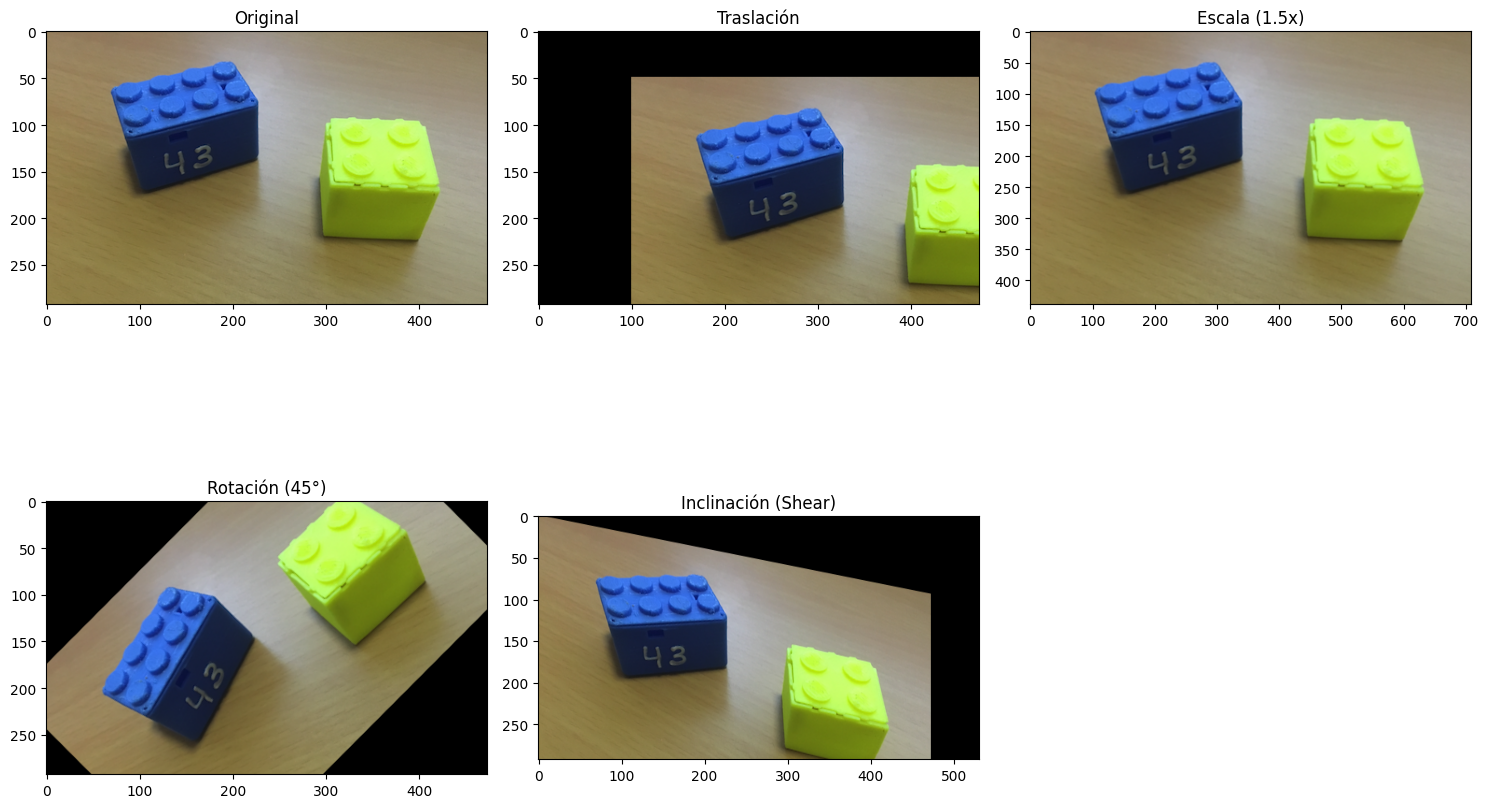

In [10]:
# Cargamos la imagen de nuevo para este ejercicio
rows, cols = img.shape[:2]

# --- 1. TRASLACIÓN ---
# Matriz: [[1, 0, tx], [0, 1, ty]]
tx, ty = 100, 50  # Desplazamiento en píxeles
M_traslacion = np.float32([[1, 0, tx], [0, 1, ty]])
img_trasladada = cv2.warpAffine(img, M_traslacion, (cols, rows))

# --- 2. ESCALA (Resizing manual con matriz) ---
# Matriz: [[sx, 0, 0], [0, sy, 0]])
sx, sy = 1.5, 1.5  # Agrandar un 50%
M_escala = np.float32([[sx, 0, 0], [0, sy, 0]])
# Al escalar, el lienzo de salida debería ser más grande para no cortar la imagen
img_escalada = cv2.warpAffine(img, M_escala, (int(cols*sx), int(rows*sy)))

# --- 3. ROTACIÓN ---
# OpenCV facilita crear la matriz con getRotationMatrix2D(centro, ángulo, escala_interna)
centro = (cols // 2, rows // 2)
M_rot = cv2.getRotationMatrix2D(centro, 45, 1.0) # 45 grados sin cambiar escala
img_rotada = cv2.warpAffine(img, M_rot, (cols, rows))

# --- 4. INCLINACIÓN (SHEAR) ---
# Esto deforma la imagen "estirándola" en un eje
shear_factor = 0.2
M_shear = np.float32([[1, 0, 0], [shear_factor, 1, 0]])
img_sheared = cv2.warpAffine(img, M_shear, (int(cols + rows*shear_factor), rows))


# Visualización comparativa
plt.figure(figsize=(15, 10))

plt.subplot(231), plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)), plt.title('Original')
plt.subplot(232), plt.imshow(cv2.cvtColor(img_trasladada, cv2.COLOR_BGR2RGB)), plt.title('Traslación')
plt.subplot(233), plt.imshow(cv2.cvtColor(img_escalada, cv2.COLOR_BGR2RGB)), plt.title('Escala (1.5x)')
plt.subplot(234), plt.imshow(cv2.cvtColor(img_rotada, cv2.COLOR_BGR2RGB)), plt.title('Rotación (45°)')
plt.subplot(235), plt.imshow(cv2.cvtColor(img_sheared, cv2.COLOR_BGR2RGB)), plt.title('Inclinación (Shear)')

plt.tight_layout()
plt.show()

Ejercicio: realizar una rotación como acumulación de inclinación (shear). Utilizar de referencia:
- https://www.ocf.berkeley.edu/~fricke/projects/israel/paeth/rotation_by_shearing.html

B) Simulación de Distorsión Radial

La distorsión radial (δr​) desplaza los puntos de la imagen siguiendo un modelo polinómico.

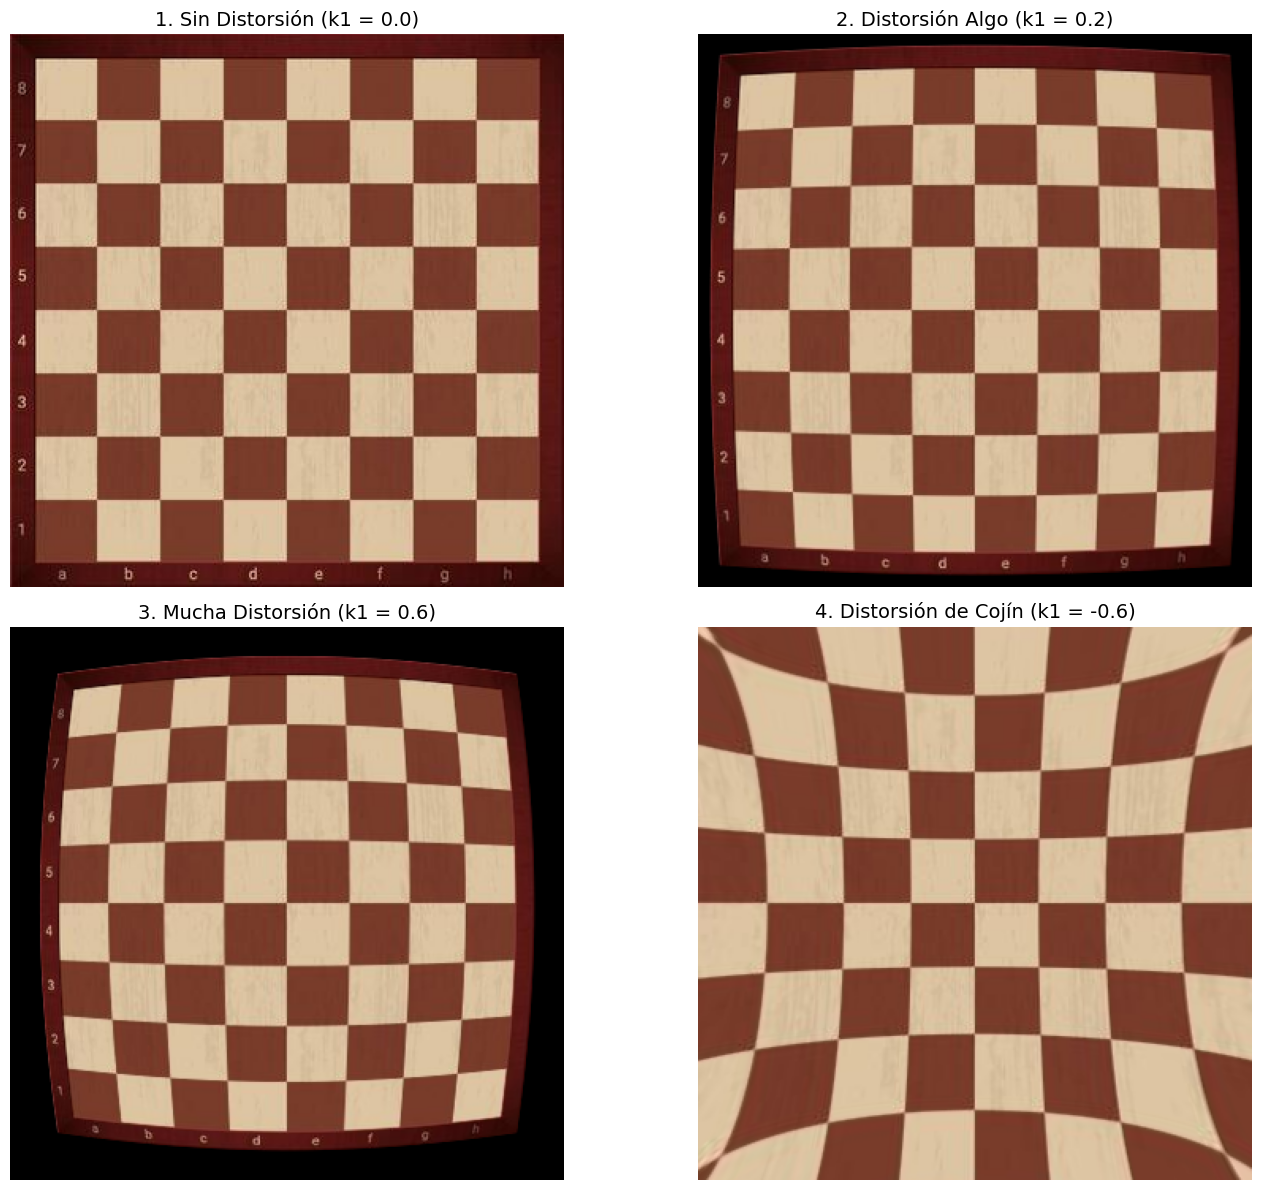

In [5]:
def aplicar_distorsion(image, k1):
    h, w = image.shape[:2]
    # Matriz intrínseca ideal (A)
    K = np.array([[w, 0, w/2], [0, w, h/2], [0, 0, 1]], dtype=float)
    # Coeficientes de distorsión [k1, k2, p1, p2, k3]
    dist_coeffs = np.array([k1, 0, 0, 0, 0], dtype=float)
    
    # Generar el mapa de distorsión
    mapx, mapy = cv2.initUndistortRectifyMap(K, dist_coeffs, None, K, (w, h), 5)
    
    # Aplicar el mapa (remap)
    return cv2.remap(image, mapx, mapy, cv2.INTER_LINEAR)

img = cv2.imread('images/Board.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_sin = aplicar_distorsion(img_rgb, 0.0)      # Sin distorsión
img_poca = aplicar_distorsion(img_rgb, 0.2)     # Distorsión leve
img_mucha = aplicar_distorsion(img_rgb, 0.6)    # Distorsión fuerte (Barril)
img_cojin = aplicar_distorsion(img_rgb, -0.6)   # Distorsión de Cojín (Efecto inverso)

# 3. Visualización comparativa
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

axes[0,0].imshow(img_sin)
axes[0,0].set_title("1. Sin Distorsión (k1 = 0.0)", fontsize=14)
axes[0,0].axis('off')

axes[0,1].imshow(img_poca)
axes[0,1].set_title("2. Distorsión Algo (k1 = 0.2)", fontsize=14)
axes[0,1].axis('off')

axes[1,0].imshow(img_mucha)
axes[1,0].set_title("3. Mucha Distorsión (k1 = 0.6)", fontsize=14)
axes[1,0].axis('off')

axes[1,1].imshow(img_cojin)
axes[1,1].set_title("4. Distorsión de Cojín (k1 = -0.6)", fontsize=14)
axes[1,1].axis('off')

plt.tight_layout()
plt.show()


# Ejercicio 3: Calibración de cámara

A) Busque un repositorio que permita calibrar una cámara usando un chessboard.
B) Con los parámetros de distorsión de la cámara, corregir la imagen.
